# Multi-Modal Product Classifier


## Kitabxana yükləmək

In [ ]:
!pip install torch torchvision transformers scikit-learn pandas pillow tqdm -q

In [90]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from transformers import DistilBertTokenizer, DistilBertModel
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

# GPU varsa, yoxsa CPU
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
import kagglehub

import pandas as pd
path = kagglehub.dataset_download("paramaggarwal/fashion-product-images-dataset")

import os
files = os.listdir(path)
print(files)

Device: cpu
Using Colab cache for faster access to the 'fashion-product-images-dataset' dataset.
['fashion-dataset']


In [99]:
base_path = os.path.join(path, "fashion-dataset")

print(os.listdir(base_path))

['images.csv', 'images', 'styles.csv', 'styles', 'fashion-dataset']


In [100]:
data = base_path + "/styles.csv"

In [101]:
df = pd.read_csv(data, on_bad_lines="skip")
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


In [102]:
img_data = base_path + "/images/"
df['image_path'] = df['id'].astype(str).apply(
    lambda x: img_data + x + ".jpg"
)

In [103]:
df['image_path'].unique()

array(['/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/15970.jpg',
       '/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/39386.jpg',
       '/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/59263.jpg',
       ...,
       '/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/18842.jpg',
       '/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/46694.jpg',
       '/kaggle/input/fashion-product-images-dataset/fashion-dataset/images/51623.jpg'],
      dtype=object)

In [184]:
df.head()

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,text,label
0,12532,Women,Apparel,Topwear,Jackets,Black,Fall,2011.0,Casual,Puma Women Solid Black Jackets,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Topwear Jackets Black Fall,1
1,3469,Unisex,Accessories,Headwear,Headband,Black,Fall,2010.0,Sports,ADIDAS Unisex Black White Headband,/kaggle/input/fashion-product-images-dataset/f...,Unisex Accessories Headwear Headband Black Fall,0
2,24742,Women,Accessories,Bags,Handbags,Green,Winter,2015.0,Casual,Murcia Women Casual Handbag,/kaggle/input/fashion-product-images-dataset/f...,Women Accessories Bags Handbags Green Winter,0
3,28477,Women,Apparel,Topwear,Kurtas,Purple,Summer,2012.0,Ethnic,Urban Yoga Women Printed Purple Kurta,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Topwear Kurtas Purple Summer,1
4,9966,Women,Apparel,Topwear,Tshirts,White,Fall,2011.0,Sports,Nike Women As Statement White T-Shirts,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Topwear Tshirts White Fall,1


In [185]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5000 non-null   int64  
 1   gender              5000 non-null   object 
 2   masterCategory      5000 non-null   object 
 3   subCategory         5000 non-null   object 
 4   articleType         5000 non-null   object 
 5   baseColour          4998 non-null   object 
 6   season              4999 non-null   object 
 7   year                5000 non-null   float64
 8   usage               4971 non-null   object 
 9   productDisplayName  4999 non-null   object 
 10  image_path          5000 non-null   object 
 11  text                5000 non-null   object 
 12  label               5000 non-null   int64  
dtypes: float64(1), int64(2), object(10)
memory usage: 507.9+ KB


In [186]:
df.isnull().sum()

,0
id,0
gender,0
masterCategory,0
subCategory,0
articleType,0
baseColour,2
season,1
year,0
usage,29
productDisplayName,1


## EDA

,count
gender,
Men,2456
Women,2108
Unisex,257
Girls,90
Boys,89


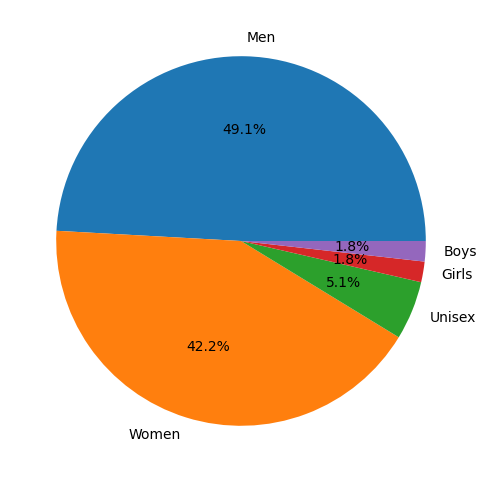

In [187]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
plt.pie(df['gender'].value_counts(), labels=df['gender'].value_counts().index, autopct='%1.1f%%');
df['gender'].value_counts()

In [193]:
df['masterCategory'].value_counts()

,count
masterCategory,
Apparel,2397
Accessories,1311
Footwear,1026
Personal Care,250
Free Items,13
Sporting Goods,3


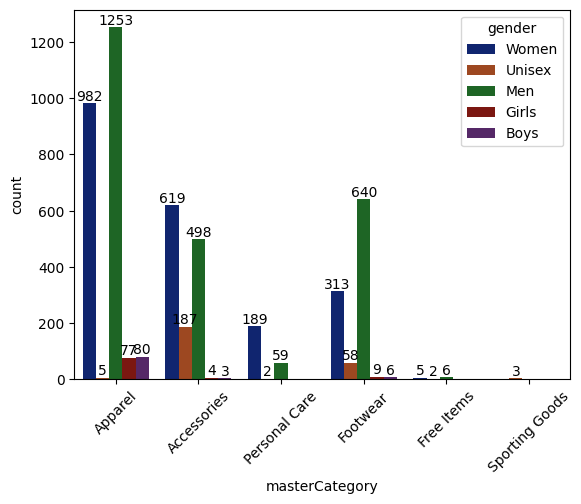

In [196]:
ax = sns.countplot(data=df, x='masterCategory', hue='gender',palette='dark')
for i in ax.containers:
  ax.bar_label(i)

plt.xticks(rotation=45);

,count
season,
Summer,2470
Fall,1263
Winter,963
Spring,303


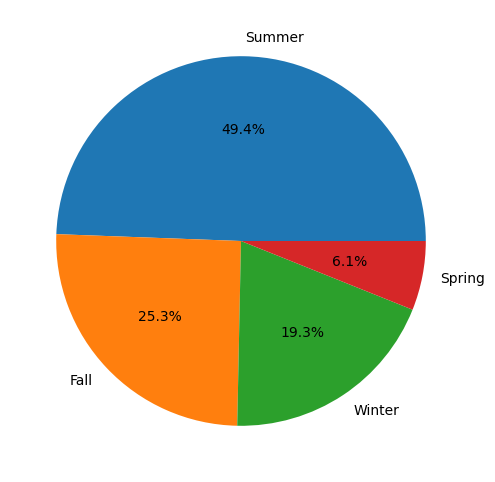

In [201]:
plt.figure(figsize=(12, 6))
plt.pie(df['season'].value_counts(), labels=df['season'].value_counts().index, autopct='%1.1f%%');

df['season'].value_counts()

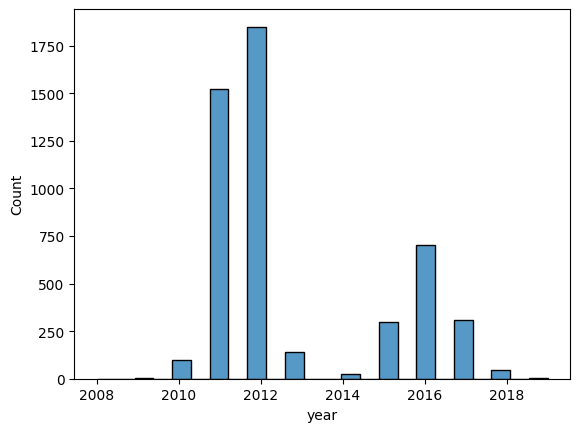

In [204]:
sns.histplot(data=df, x='year');

In [206]:
df['usage'].value_counts()

,count
usage,
Casual,3886
Sports,425
Ethnic,369
Formal,282
Party,4
Smart Casual,3
Travel,2


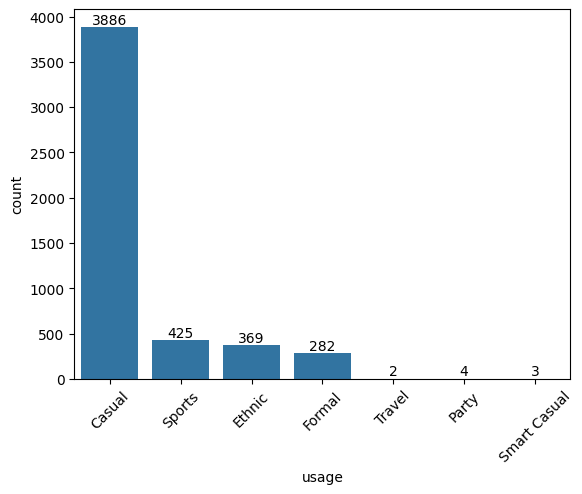

In [208]:
ax = sns.countplot(data=df, x='usage')
for i in ax.containers:
  ax.bar_label(i)

plt.xticks(rotation=45);

In [106]:
def build_text(row):
    parts = [
        row.get('gender', ''),
        row.get('masterCategory', ''),
        row.get('subCategory', ''),
        row.get('articleType', ''),
        row.get('baseColour', ''),
        row.get('season', '')
    ]
    return " ".join([str(p) for p in parts if pd.notna(p)])

df['text'] = df.apply(build_text, axis=1)

In [212]:
df.head(3)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,text,label
0,12532,Women,Apparel,Topwear,Jackets,Black,Fall,2011.0,Casual,Puma Women Solid Black Jackets,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Topwear Jackets Black Fall,1
1,3469,Unisex,Accessories,Headwear,Headband,Black,Fall,2010.0,Sports,ADIDAS Unisex Black White Headband,/kaggle/input/fashion-product-images-dataset/f...,Unisex Accessories Headwear Headband Black Fall,0
2,24742,Women,Accessories,Bags,Handbags,Green,Winter,2015.0,Casual,Murcia Women Casual Handbag,/kaggle/input/fashion-product-images-dataset/f...,Women Accessories Bags Handbags Green Winter,0


In [108]:
top_classes = df['masterCategory'].value_counts().nlargest(TOP_N_CLASSES).index
df = df[df['masterCategory'].isin(top_classes)].reset_index(drop=True)

In [109]:
if MAX_SAMPLES:
    df = df.sample(n=min(MAX_SAMPLES, len(df)), random_state=42).reset_index(drop=True)
df.head(2)

,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,image_path,text
0,12532,Women,Apparel,Topwear,Jackets,Black,Fall,2011.0,Casual,Puma Women Solid Black Jackets,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Topwear Jackets Black Fall
1,3469,Unisex,Accessories,Headwear,Headband,Black,Fall,2010.0,Sports,ADIDAS Unisex Black White Headband,/kaggle/input/fashion-product-images-dataset/f...,Unisex Accessories Headwear Headband Black Fall


In [111]:
NUM_CLASSES

6

## Dataset clasterləşdirmək


In [113]:
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

img_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225]),
])

class ProductDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Şəkil
        try:
            img = Image.open(row['img_path']).convert('RGB')
        except:
            img = Image.new('RGB', (IMG_SIZE, IMG_SIZE))
        img = img_transform(img)

        # Mətn
        enc = tokenizer(
            row['text'],
            max_length=MAX_LEN,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        input_ids      = enc['input_ids'].squeeze(0)
        attention_mask = enc['attention_mask'].squeeze(0)

        label = torch.tensor(row['label'], dtype=torch.long)
        return img, input_ids, attention_mask, label

In [135]:
target_col = "masterCategory"

In [213]:
# Hiperparametrlər
img_size    = 64
max_len     = 16
batch_size  = 32
epoch      = 3
lr          = 1e-5
max_samples = 5000
top_n_classes = 10

## Train Val ayırmaq, DataLoader yaratmaq

In [136]:
le = LabelEncoder()
df['label'] = le.fit_transform(df['masterCategory'])
NUM_CLASSES = len(le.classes_)

In [142]:
df_model = df[["image_path", "text", "label"]].copy()

df_model = df_model.dropna(subset=["image_path", "text", "label"])
df_model = df_model[df_model["text"].str.strip() != ""]

In [147]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model['label'],
    random_state=42
)

# index reset
train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

# balans yoxlama
print("Train label distribution:")
print(train_df['label'].value_counts(normalize=True))

print("\n Val label distribution:")
print(val_df['label'].value_counts(normalize=True))

Train label distribution:
label
1    0.47950
0    0.26225
2    0.20525
4    0.05000
3    0.00250
5    0.00050
Name: proportion, dtype: float64

Val label distribution:
label
1    0.479
0    0.262
2    0.205
4    0.050
3    0.003
5    0.001
Name: proportion, dtype: float64


In [163]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(df_model, test_size=0.2, random_state=42, stratify=df_model['label'])

train_loader = DataLoader(ProductDataset(train_df), batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
val_loader   = DataLoader(ProductDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

In [165]:
val_df.head()

,image_path,text,label
2673,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Loungewear and Nightwear Nightdr...,1
3808,/kaggle/input/fashion-product-images-dataset/f...,Men Footwear Shoes Casual Shoes Grey Summer,2
3580,/kaggle/input/fashion-product-images-dataset/f...,Women Apparel Topwear Tops White Fall,1
3282,/kaggle/input/fashion-product-images-dataset/f...,Women Accessories Bags Handbags Gold Summer,0
153,/kaggle/input/fashion-product-images-dataset/f...,Men Footwear Shoes Casual Shoes Navy Blue Winter,2


## ResNet-18 / DistilBERT / Fusion / Classifier

In [211]:
'''
The model has two branches. ResNet extracts 512 features from the image. DistilBERT extracts 768
features from the text using the CLS token. These two features are concatenated into 1280
dimensions. The classifier reduces 1280 to 256, passes through ReLU and Dropout, then outputs
the number of classes. Most of DistilBERT is frozen; only the last 2 layers are trainable. All of
ResNet is trainable. This model is built for 6 categories.
'''

'\nThe model has two branches. ResNet extracts 512 features from the image. DistilBERT extracts 768 \nfeatures from the text using the CLS token. These two features are concatenated into 1280 \ndimensions. The classifier reduces 1280 to 256, passes through ReLU and Dropout, then outputs \nthe number of classes. Most of DistilBERT is frozen; only the last 2 layers are trainable. All of\nResNet is trainable. This model is built for 6 categories.\n'

In [166]:
class MultiModalModel(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        # ResNet-18
        resnet = models.resnet18(weights='DEFAULT')
        resnet.fc = nn.Identity()           # son layeri sil, feature al
        self.img_encoder = resnet           # çıxış: 512

        # DistilBERT
        self.text_encoder = DistilBertModel.from_pretrained('distilbert-base-uncased')
        # Yalnız son 2 layeri train edir qalanı donur
        for param in self.text_encoder.parameters():
            param.requires_grad = False
        for param in self.text_encoder.transformer.layer[-2:].parameters():
            param.requires_grad = True

        # Fusion  Classifier
        # 512 (resnet) + 768 (distilbert) = 1280
        self.classifier = nn.Sequential(
            nn.Linear(512 + 768, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, img, input_ids, attention_mask):
        # Şəkil feature-ları
        img_feat = self.img_encoder(img)

        # CLS token
        text_out = self.text_encoder(input_ids=input_ids,
                                     attention_mask=attention_mask)
        text_feat = text_out.last_hidden_state[:, 0, :]


        combined = torch.cat([img_feat, text_feat], dim=1)
        return self.classifier(combined)


model = MultiModalModel(NUM_CLASSES).to(DEVICE)
print('Model hazırdır!')
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parametr sayı: {total_params:,}')

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model hazırdır!
Trainable parametr sayı: 25,681,734


## Training

In [167]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

def run_epoch(loader, train=True):
    if train:
        model.train()
    else:
        model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()

    with ctx:
        for batch in tqdm(loader, leave=False):

            img        = batch['image'].to(DEVICE)
            input_ids  = batch['input_ids'].to(DEVICE)
            attn_mask  = batch['attention_mask'].to(DEVICE)
            labels     = batch['label'].to(DEVICE)

            logits = model(img, input_ids, attn_mask)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    return avg_loss, macro_f1

## Model Qiymətləndirmə

In [209]:
"""
    Executes one complete pass through the dataset (either training or validation)

    Args:
        loader: DataLoader object containing batches of (image, text, mask, labels)
        train: Boolean flag - True for training mode, False for evaluation mode

    Returns:
        avg_loss: Average loss over all batches
        macro_f1: Macro-averaged F1 score across all classes

    What this function does:
        1. Sets model to train/eval mode (affects dropout, batch norm behavior)
        2. Iterates through all batches in the dataloader
        3. For each batch:
           - Moves data to CPU device
           - Passes image + text through model to get predictions (logits)
           - Calculates loss between predictions and true labels
           - If training: computes gradients and updates model weights
           - Collects predictions and labels for final F1 calculation
        4. Returns average loss and macro F1 score
    """

'\n    Executes one complete pass through the dataset (either training or validation)\n    \n    Args:\n        loader: DataLoader object containing batches of (image, text, mask, labels)\n        train: Boolean flag - True for training mode, False for evaluation mode\n    \n    Returns:\n        avg_loss: Average loss over all batches\n        macro_f1: Macro-averaged F1 score across all classes\n    \n    What this function does:\n        1. Sets model to train/eval mode (affects dropout, batch norm behavior)\n        2. Iterates through all batches in the dataloader\n        3. For each batch:\n           - Moves data to CPU device\n           - Passes image + text through model to get predictions (logits)\n           - Calculates loss between predictions and true labels\n           - If training: computes gradients and updates model weights\n           - Collects predictions and labels for final F1 calculation\n        4. Returns average loss and macro F1 score\n    '

In [168]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR)

def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, all_preds, all_labels = 0, [], []

    ctx = torch.no_grad() if not train else torch.enable_grad()
    with ctx:
        for img, input_ids, attn_mask, labels in tqdm(loader, leave=False):
            img        = img.to(DEVICE)
            input_ids  = input_ids.to(DEVICE)
            attn_mask  = attn_mask.to(DEVICE)
            labels     = labels.to(DEVICE)

            logits = model(img, input_ids, attn_mask)
            loss   = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            total_loss += loss.item()
            preds = logits.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    return avg_loss, macro_f1

print(f'{"Epoch":<8} {"Train Loss":<12} {"Train F1":<12} {"Val Loss":<12} {"Val F1"}')
print('-' * 56)

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_f1 = run_epoch(train_loader, train=True)
    vl_loss, vl_f1 = run_epoch(val_loader,   train=False)
    print(f'{epoch:<8} {tr_loss:<12.4f} {tr_f1:<12.4f} {vl_loss:<12.4f} {vl_f1:.4f}')

Epoch    Train Loss   Train F1     Val Loss     Val F1
--------------------------------------------------------


1        0.1230       0.6336       0.0101       0.8330


2        0.0045       0.8253       0.0066       0.8330


3        0.0031       0.8166       0.0027       0.8095


In [175]:
model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for img, input_ids, attn_mask, labels in val_loader:

        img        = img.to(DEVICE)
        input_ids  = input_ids.to(DEVICE)
        attn_mask  = attn_mask.to(DEVICE)
        labels     = labels.to(DEVICE)

        logits = model(img, input_ids, attn_mask)

        preds = torch.argmax(logits, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


In [176]:
macro_f1 = f1_score(all_labels, all_preds, average="macro")
print("Macro F1:", macro_f1)

Macro F1: 0.8095238095238096


In [177]:
print(classification_report(
    all_labels,
    all_preds,
    target_names=le.classes_,
    zero_division=0
))

macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
print("Macro F1:", macro_f1)

                precision    recall  f1-score   support

   Accessories       1.00      1.00      1.00       262
       Apparel       1.00      1.00      1.00       479
      Footwear       1.00      1.00      1.00       205
    Free Items       0.75      1.00      0.86         3
 Personal Care       1.00      1.00      1.00        50
Sporting Goods       0.00      0.00      0.00         1

      accuracy                           1.00      1000
     macro avg       0.79      0.83      0.81      1000
  weighted avg       1.00      1.00      1.00      1000

Macro F1: 0.8095238095238096


In [178]:
print(set(all_labels))
print(len(le.classes_))

{np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)}
6


In [ ]:
# Modeli yadda saxlaamaq
torch.save(model.state_dict(), 'multimodal_model.pth')

In [183]:
# all_labels

In [182]:
# all_preds